In [1]:
# setup, make notebooks/_utils.py importable from the repo root or from notebooks/
import sys, os
# quiet two harmless-but-noisy libs. must be set before sentence-transformers imports
# tokenizers (cell below): its rust tokenizer uses parallelism, then umap/hdbscan fork
# worker processes and tokenizers warns once per fork. KMP_WARNINGS silences the
# openmp info line ("omp_set_nested deprecated") from the native libs behind hdbscan.
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('KMP_WARNINGS', '0')
for _cand in (os.getcwd(), os.path.join(os.getcwd(), 'notebooks'), os.path.dirname(os.getcwd())):
    if os.path.isfile(os.path.join(_cand, '_utils.py')) and _cand not in sys.path:
        sys.path.insert(0, _cand)
        break
from _utils import pick_device, set_seed
device = pick_device()
print(f'using device: {device}')

using device: mps


In [2]:
import time
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
pd.set_option('max_colwidth', None)
pd.set_option('display.max_columns', None)

/Users/jesuslealtrujillo/Documents/git/website_tutorials/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# set SMOKE_TEST=1 for a quick run on a subsample, leave unset to reproduce the full corpus run
SMOKE_TEST = os.environ.get('SMOKE_TEST', '0') == '1'
if SMOKE_TEST:
    N_DOCS, MIN_CLUSTER_SIZE, MIN_SAMPLES, MIN_DF = 2000, 20, 5, 3
else:
    N_DOCS, MIN_CLUSTER_SIZE, MIN_SAMPLES, MIN_DF = None, 60, 5, 10
SUFFIX = '_smoke' if SMOKE_TEST else ''   # keep smoke + full corpus caches separate
set_seed(192)
print(f'SMOKE_TEST={SMOKE_TEST}  N_DOCS={N_DOCS}  MIN_CLUSTER_SIZE={MIN_CLUSTER_SIZE}  '
      f'MIN_SAMPLES={MIN_SAMPLES}  MIN_DF={MIN_DF}')

SMOKE_TEST=False  N_DOCS=None  MIN_CLUSTER_SIZE=60  MIN_SAMPLES=5  MIN_DF=10


In [4]:
# read the reviews, same length filter as the etm notebooks
pitchfork = pd.read_csv('../data/pitchfork/pitchfork.csv', low_memory=False,
                        encoding='utf-8')
print(len(pitchfork))
pitchfork['review'] = pitchfork['review'].astype(str)
pitchfork = pitchfork[pitchfork['review'].apply(lambda x: len(x) > 200)]
pitchfork.reset_index(inplace=True)
print(len(pitchfork))
if N_DOCS:
    pitchfork = pitchfork.head(N_DOCS).reset_index(drop=True)
    print('subsampled to', len(pitchfork))

25709
25705


In [5]:
# same stopword list as the etm notebooks, here it only shapes the ctfidf topic words,
# the sentence model sees the raw text untouched. a plain custom list only strips the
# exact strings it contains, so we union three sources to avoid leaks: spacy's list
# (stop.txt), sklearn's own english list (a handful of words spacy omits), and the
# contraction stems sklearn's default tokenizer leaves behind -- it splits on the
# apostrophe, so "doesn't" -> "doesn", "you've" -> "ve", none of which are stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

with open('../data/pitchfork/stop.txt', 'r') as f:
    stop_words = f.read().split('\n')
stop_words = stop_words+['songs', 'albums','record','records', 'album', 'sound', 'music',
                        'band', 'song', 'time', 'years','fuck', '\\xa0', 'kind','single','shit',
                         'good', '\n', 'great','\xa0', 'sing','rock','bad','guy','lyric',
                        'lot', 'sing','band','rock','man','girl','listen','day','bands','record',
                         'records', 'guitars','thing','pretty','artist','things',
                         'people','stuff','guitar']
contraction_stems = {'aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven',
                     'isn', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren',
                     'won', 'wouldn', 'ain', 'll', 're', 've'}
stop_words = sorted(set(stop_words) | set(ENGLISH_STOP_WORDS) | contraction_stems)

In [6]:
# bertopic works on the raw reviews, no lemmatization and no bows, that is the point
# of the comparison, same split seed as the etm so both models see identical test docs
documents = pitchfork['review'].tolist()
doc_ids = pitchfork['link'].tolist()
x_train, x_test = train_test_split(documents, test_size=0.15, random_state=192)
ids_train, ids_test = train_test_split(doc_ids, test_size=0.15, random_state=192)
#if not SMOKE_TEST:
#    assert len(x_train) == 17738 and len(x_test) == 3131  # must match the etm notebooks
print(f'train {len(x_train)} test {len(x_test)}')

train 21849 test 3856


In [7]:
# embed every review once and cache to disk, encoding is the only gpu stage in
# bertopic and there is no reason to ever recompute it, minilm truncates at 256
# word pieces so it mostly sees the opening of each review. both encoders run
# here back to back, before anything downstream is fitted, see the cell below
EMB_NAME = 'all-MiniLM-L6-v2'
emb_path = f'../data/pitchfork/bertopic_minilm{SUFFIX}.npy'
st_model = SentenceTransformer(EMB_NAME, device=str(device))
minilm_minutes = None
override_embeddings = True
if os.path.exists(emb_path) and not override_embeddings:
    embeddings = np.load(emb_path)
    print(f'loaded cached embeddings {embeddings.shape}')
else:
    start = time.time()
    embeddings = st_model.encode(documents, batch_size=256 if device.type == 'cuda' else 64,
                                 show_progress_bar=True)
    minilm_minutes = (time.time() - start) / 60
    np.save(emb_path, embeddings)
    print(f'encoded {embeddings.shape} in {minilm_minutes:.1f} minutes')
emb_train, emb_test = train_test_split(embeddings, test_size=0.15, random_state=192)

Batches: 100%|██████████| 402/402 [01:02<00:00,  6.42it/s]

encoded (25705, 384) in 1.0 minutes


In [8]:
# mpnet next, encoded here rather than down in its own section. the encoder shares
# unified memory with everything the pipeline leaves resident once it has run -- a
# fitted umap and its knn graph, hdbscan prediction data, the soft membership
# matrix -- and encoding after all of that cost 59.6 minutes against 8.7 in an
# empty kernel, the same work at seven times the wall clock. so both models encode
# while nothing else is allocated and the pipelines below run off the arrays.
# mpnet is 768d and about twelve times slower per document than minilm, twice the
# layers at twice the width, reading a 384 token window against minilm's 256
EMB_NAME_2 = 'all-mpnet-base-v2'
emb_path_2 = f'../data/pitchfork/bertopic_mpnet{SUFFIX}.npy'
st_model_2 = SentenceTransformer(EMB_NAME_2, device=str(device))
mpnet_minutes = None
override_embeddings = True
if os.path.exists(emb_path_2) and not override_embeddings:
    embeddings_mpnet = np.load(emb_path_2)
    print(f'loaded cached embeddings {embeddings_mpnet.shape}')
else:
    start = time.time()
    embeddings_mpnet = st_model_2.encode(documents, batch_size=128 if device.type == 'cuda' else 32,
                                         show_progress_bar=True)
    mpnet_minutes = (time.time() - start) / 60
    np.save(emb_path_2, embeddings_mpnet)
    print(f'encoded {embeddings_mpnet.shape} in {mpnet_minutes:.1f} minutes')
emb2_train, emb2_test = train_test_split(embeddings_mpnet, test_size=0.15, random_state=192)

Batches: 100%|██████████| 804/804 [09:57<00:00,  1.35it/s]

encoded (25705, 768) in 10.0 minutes


In [9]:
# the standard bertopic stack, umap squeezes the embeddings to 5d, hdbscan finds
# the clusters, ctfidf turns each cluster into a word list, the vectorizer gets the
# same stopwords as the etm plus bigrams since the etm vocab has gensim phrases,
# random_state pins umap to a single thread, slower but reproducible
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=192)
# min_samples sits well below min_cluster_size on purpose, these reviews embed into
# one big dense blob and with the default coupling hdbscan either finds two giant
# clusters or a hundred micro topics, both with most of the corpus marked as noise
hdbscan_model = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                        metric='euclidean', cluster_selection_method='eom',
                        prediction_data=True)
# sklearn warns that a few list entries are not valid tokens, that is fine
vectorizer_model = CountVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=MIN_DF)
topic_model = BERTopic(embedding_model=st_model, umap_model=umap_model,
                       hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
                       calculate_probabilities=True, top_n_words=10, verbose=True)

In [10]:
# fit on the train split only, like the etm, so transform on the test docs later
# is honest inference on unseen documents
start = time.time()
topics_train, probs_train = topic_model.fit_transform(x_train, embeddings=emb_train)
fit_minutes = (time.time() - start) / 60
print(f'umap + hdbscan + ctfidf took {fit_minutes:.1f} minutes')

2026-08-05 11:09:08,913 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-08-05 11:09:24,731 - BERTopic - Dimensionality - Completed ✓


2026-08-05 11:09:24,731 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-08-05 11:09:26,682 - BERTopic - Cluster - Completed ✓


2026-08-05 11:09:26,685 - BERTopic - Representation - Extracting topics from clusters using representation models.


2026-08-05 11:09:32,291 - BERTopic - Representation - Completed ✓


umap + hdbscan + ctfidf took 0.4 minutes


In [11]:
# hdbscan picks the topic count on its own and parks everything it cannot place in -1
info = topic_model.get_topic_info()
outlier_share = (np.array(topics_train) == -1).mean()
print(f'{len(info) - 1} topics found, {outlier_share:.1%} of the train docs are outliers')
info[['Topic', 'Count', 'Name']].head(12)

27 topics found, 59.0% of the train docs are outliers


,Topic,Count,Name
0,-1,12900,-1_like_new_pop_sounds
1,0,2107,0_like_voice_pop_love
2,1,1915,1_rap_like_rapper_hop
3,2,779,2_like_country_dylan_young
4,3,687,3_house_techno_dance_dj
5,4,621,4_metal_black_black metal_death
6,5,292,5_like_punk_indie_new
7,6,291,6_like_live_new_way
8,7,217,7_japanese_like_japan_sounds
9,8,204,8_beach_sea_like_islands


In [12]:
# how sensitive is all this to the clustering knobs, rerun hdbscan on the fitted
# umap reduction with other settings, the topic count moves a lot but the outlier
# share barely budges, most of this corpus sits in low density space
reduced_train = topic_model.umap_model.embedding_
for mcs, ms in [(10, None), (15, 5), (60, 5), (100, 10), (150, 20)]:
    h = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean',
                cluster_selection_method='eom').fit(reduced_train)
    labels = h.labels_
    print(f'min_cluster_size={mcs:>3} min_samples={str(ms):>4}: '
          f'{labels.max() + 1:>3} clusters, {(labels == -1).mean():.1%} outliers')

min_cluster_size= 10 min_samples=None: 272 clusters, 62.5% outliers


min_cluster_size= 15 min_samples=   5: 207 clusters, 53.0% outliers


min_cluster_size= 60 min_samples=   5:  27 clusters, 59.0% outliers


min_cluster_size=100 min_samples=  10:  14 clusters, 53.0% outliers


min_cluster_size=150 min_samples=  20:   9 clusters, 54.2% outliers


In [13]:
# merge down to the etm's 20 topics, nr_topics counts the -1 row so 21 leaves 20 real topics
topic_model.reduce_topics(x_train, nr_topics=21)
topics_train = list(topic_model.topics_)
probs_train = topic_model.probabilities_
info = topic_model.get_topic_info()
outlier_share = (np.array(topics_train) == -1).mean()
print(f'{len(info) - 1} topics after reduction, outlier share {outlier_share:.1%}')
info[['Topic', 'Count', 'Name']]

2026-08-05 11:09:35,121 - BERTopic - Topic reduction - Reducing number of topics


2026-08-05 11:09:40,891 - BERTopic - Topic reduction - Reduced number of topics from 28 to 21


20 topics after reduction, outlier share 59.0%


,Topic,Count,Name
0,-1,12900,-1_like_new_pop_sounds
1,0,2178,0_like_voice_pop_love
2,1,1982,1_rap_like_rapper_hop
3,2,861,2_like_country_new_dylan
4,3,687,3_house_techno_dance_like
5,4,626,4_like_punk_new_pop
6,5,621,5_metal_black_black metal_death
7,6,291,6_like_live_new_way
8,7,217,7_japanese_like_japan_sounds
9,8,204,8_beach_like_sea_islands


In [14]:
# the 20 topics with ten words each, same style as the etm printout
for topic_id in sorted(t for t in topic_model.get_topics() if t != -1):
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    print(f'topic {topic_id}: {words}')

topic 0: ['like', 'voice', 'pop', 'love', 'sings', 'new', 'track', 'sounds', 'self', 'way']
topic 1: ['rap', 'like', 'rapper', 'hop', 'hip hop', 'hip', 'new', 'beats', 'rappers', 'raps']
topic 2: ['like', 'country', 'new', 'dylan', 'young', 'folk', 'voice', 'oldham', 'old', 'sounds']
topic 3: ['house', 'techno', 'dance', 'like', 'dj', 'tracks', 'mix', 'bass', 'track', 'label']
topic 4: ['like', 'punk', 'new', 'pop', 'indie', 'hardcore', 'emo', 'post', 'way', 'debut']
topic 5: ['metal', 'black', 'black metal', 'death', 'like', 'death metal', 'doom', 'riffs', 'new', 'hardcore']
topic 6: ['like', 'live', 'new', 'way', 'pop', 'tracks', 'political', 'set', 'label', 'best']
topic 7: ['japanese', 'like', 'japan', 'sounds', 'pop', 'tokyo', 'tracks', 'track', 'new', 'matmos']
topic 8: ['beach', 'like', 'sea', 'islands', 'pop', 'surf', 'sounds', 'way', 'indie', 'debut']
topic 9: ['like', 'track', 'sun', 'earth', 'sounds', 'tracks', 'new', 'work', 'way', 'feel']
topic 10: ['african', 'africa', 'l

In [15]:
# same diversity metric as the etm, share of unique words across the top 200 of each
# topic, get_topic only carries the ten display words so rank the full ctfidf rows
def get_topic_diversity(model, topk=200):
    offset = 1 if -1 in model.get_topics() else 0   # first ctfidf row is the -1 bucket
    ctfidf = model.c_tf_idf_.toarray()[offset:]
    top_idx = np.argsort(ctfidf, axis=1)[:, -topk:]
    n_unique = len(np.unique(top_idx))
    return n_unique / (topk * ctfidf.shape[0])

td = get_topic_diversity(topic_model, topk=200)
print(f'topic diversity at 200 words: {td:.3f} (the etm got 0.367)')

topic diversity at 200 words: 0.282 (the etm got 0.367)


In [16]:
# give every train doc a topic for the head to head tables, the probabilities
# strategy uses hdbscan's soft membership, the fitted topic words above stay untouched,
# updating them here would fold the outlier docs back into the ctfidf
new_topics = topic_model.reduce_outliers(x_train, topics_train,
                                         strategy='probabilities', probabilities=probs_train)
print(f'outliers before {sum(t == -1 for t in topics_train)}, after {sum(t == -1 for t in new_topics)}')

outliers before 12900, after 0


In [17]:
# where the outlier docs ended up
pd.Series(new_topics).value_counts().sort_index()

0     3286
1     2629
2     1876
3     1008
4     8035
5      639
6      303
7      242
8      209
9     1978
10     237
11     198
12     189
13     257
14     118
15     184
16      70
17      62
18     223
19     106
Name: count, dtype: int64

In [18]:
# inference on the held out test docs, embeddings are passed in so nothing is re-encoded
start = time.time()
topics_test, probs_test = topic_model.transform(x_test, embeddings=emb_test)
transform_seconds = time.time() - start
# same outlier treatment as the train side
topics_test_full = [int(np.argmax(p)) if t == -1 else int(t) for t, p in zip(topics_test, probs_test)]
print(f'assigned {len(topics_test)} test docs in {transform_seconds:.1f} seconds, '
      f'{sum(t == -1 for t in topics_test)} came back as outliers')

2026-08-05 11:09:41,899 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


2026-08-05 11:09:47,447 - BERTopic - Dimensionality - Completed ✓


2026-08-05 11:09:47,448 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


2026-08-05 11:09:47,512 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN


2026-08-05 11:09:47,709 - BERTopic - Probabilities - Completed ✓


2026-08-05 11:09:47,709 - BERTopic - Cluster - Completed ✓


assigned 3856 test docs in 5.8 seconds, 2642 came back as outliers


In [19]:
# join the assignments back to the review metadata
meta = pitchfork[['artist', 'album', 'genre', 'score', 'link']].drop_duplicates('link')
test_df = pd.DataFrame({'link': ids_test, 'topic': topics_test_full,
                        'prob': probs_test.max(axis=1).round(3)})
test_df = test_df.merge(meta, on='link', how='left')
test_df.head()

,link,topic,prob,artist,album,genre,score
0,pf_015290,4,0.061,The Black Twig Pickers,Ironto Special,Folk/Country,7.2
1,pf_008132,16,0.825,Audio Push,The Stone Junction,Rap,7.1
2,pf_014260,5,0.376,Absu,Abzu,Metal,7.4
3,pf_006876,13,0.762,WALL,Untitled,Rock,7.6
4,pf_002987,16,0.125,Black Marble,I Must Be Living Twice EP,Rock,6.9


In [20]:
# the three test docs tracked in the etm notebook, there gibbs put 0.62 on the rap
# topic, the ramblin jack elliott record 0.93 on country folk and the stax compilation
# 0.61 on soul funk with its second weight on reissues
mask = (test_df['artist'].str.contains('Freddie Gibbs|Ramblin', na=False) |
        test_df['album'].str.contains('Stax', case=False, na=False))
for i in test_df.index[mask]:
    top3 = np.argsort(probs_test[i])[::-1][:3]
    print(f"{test_df.loc[i, 'artist']} - {test_df.loc[i, 'album']}: "
          f"{[(int(t), round(float(probs_test[i][t]), 2)) for t in top3]}")
test_df[mask]

Freddie Gibbs - ESGN: [(1, 0.72), (4, 0.05), (2, 0.03)]
Freddie Gibbs - Freddie: [(1, 0.87), (4, 0.02), (2, 0.01)]
Various Artists - Soul’d Out: The Complete Wattstax Collection: [(4, 0.13), (6, 0.03), (9, 0.02)]


,link,topic,prob,artist,album,genre,score
737,pf_011294,1,0.717,Freddie Gibbs,ESGN,Rap,6.9
2986,pf_005451,1,0.869,Freddie Gibbs,Freddie,Rap,7.8
2997,pf_000391,4,0.126,Various Artists,Soul’d Out: The Complete Wattstax Collection,NaN,9.1


2d umap took 0.2 minutes


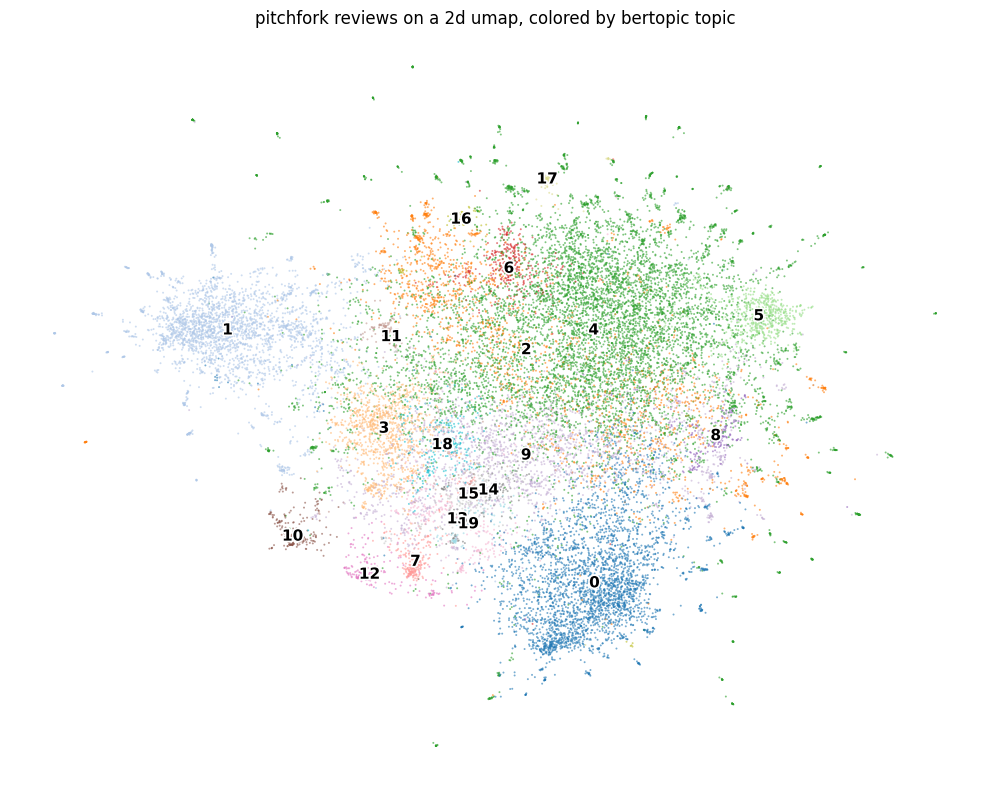

In [21]:
# map the train docs to 2d with the same umap settings to look at the cluster shape,
# numbers sit on each topic centroid so the colors only carry identity
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

start = time.time()
xy = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine',
          random_state=192).fit_transform(emb_train)
print(f'2d umap took {(time.time() - start) / 60:.1f} minutes')

topics_arr = np.array(new_topics)
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(xy[:, 0], xy[:, 1], c=topics_arr, cmap='tab20', s=2, alpha=0.6, linewidths=0)
for t in sorted(set(topics_arr)):
    cx, cy = np.median(xy[topics_arr == t], axis=0)
    ax.text(cx, cy, str(t), fontsize=11, fontweight='bold', ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
ax.set_title('pitchfork reviews on a 2d umap, colored by bertopic topic')
ax.axis('off')
plt.tight_layout()
plt.show()

In [22]:
# rerun the whole pipeline with the bigger mpnet model to see what the extra
# quality buys, fresh copies of every component, reusing fitted ones would leak
# state between models
umap_model_2 = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                    metric='cosine', random_state=192)
hdbscan_model_2 = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                          metric='euclidean', cluster_selection_method='eom',
                          prediction_data=True)
vectorizer_model_2 = CountVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=MIN_DF)
topic_model_2 = BERTopic(embedding_model=st_model_2, umap_model=umap_model_2,
                         hdbscan_model=hdbscan_model_2, vectorizer_model=vectorizer_model_2,
                         calculate_probabilities=True, top_n_words=10, verbose=True)
start = time.time()
topics2_train, probs2_train = topic_model_2.fit_transform(x_train, embeddings=emb2_train)
fit2_minutes = (time.time() - start) / 60
info2 = topic_model_2.get_topic_info()
print(f'fit took {fit2_minutes:.1f} minutes, {len(info2) - 1} topics found, '
      f'{(np.array(topics2_train) == -1).mean():.1%} outliers')

2026-08-05 11:10:02,224 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-08-05 11:10:16,543 - BERTopic - Dimensionality - Completed ✓


2026-08-05 11:10:16,544 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-08-05 11:10:17,466 - BERTopic - Cluster - Completed ✓


2026-08-05 11:10:17,469 - BERTopic - Representation - Extracting topics from clusters using representation models.


2026-08-05 11:10:23,316 - BERTopic - Representation - Completed ✓


fit took 0.4 minutes, 29 topics found, 56.3% outliers


In [23]:
# same reduction to 20 real topics
topic_model_2.reduce_topics(x_train, nr_topics=21)
topics2_train = list(topic_model_2.topics_)
probs2_train = topic_model_2.probabilities_
td2 = get_topic_diversity(topic_model_2, topk=200)
print(f'outlier share {(np.array(topics2_train) == -1).mean():.1%} after reduction')
print(f'mpnet topic diversity at 200 words: {td2:.3f} vs {td:.3f} for minilm')
for topic_id in sorted(t for t in topic_model_2.get_topics() if t != -1):
    words = [w for w, _ in topic_model_2.get_topic(topic_id)]
    print(f'topic {topic_id}: {words}')

2026-08-05 11:10:24,308 - BERTopic - Topic reduction - Reducing number of topics


2026-08-05 11:10:30,173 - BERTopic - Topic reduction - Reduced number of topics from 30 to 21


outlier share 56.3% after reduction
mpnet topic diversity at 200 words: 0.305 vs 0.282 for minilm
topic 0: ['like', 'tracks', 'sounds', 'track', 'house', 'techno', 'new', 'work', 'dance', 'electronic']
topic 1: ['rap', 'like', 'rapper', 'hop', 'hip hop', 'hip', 'raps', 'new', 'beats', 'rappers']
topic 2: ['metal', 'like', 'black', 'death', 'hardcore', 'punk', 'new', 'doom', 'track', 'death metal']
topic 3: ['like', 'pop', 'love', 'voice', 'sings', 'new', 'self', 'singer', 'track', 'debut']
topic 4: ['country', 'young', 'like', 'dylan', 'cash', 'new', 'folk', 'old', 'voice', 'sounds']
topic 5: ['like', 'pop', 'emo', 'new', 'british', 'indie', 'way', 'self', 'debut', 'punk']
topic 6: ['like', 'spanish', 'el', 'brazilian', 'sounds', 'la', 'latin', 'track', 'new', 'pop']
topic 7: ['african', 'africa', 'like', 'afrobeat', 'western', 'world', 'sounds', 'country', 'west', 'nigerian']
topic 8: ['punk', 'political', 'like', 'new', 'hardcore', 'casey', 'flag', 'lyrics', 'war', 'world']
topic 9: 

In [24]:
# mpnet inference on the same three tracked test docs
start = time.time()
topics2_test, probs2_test = topic_model_2.transform(x_test, embeddings=emb2_test)
transform2_seconds = time.time() - start
topics2_test_full = [int(np.argmax(p)) if t == -1 else int(t) for t, p in zip(topics2_test, probs2_test)]
test_df2 = pd.DataFrame({'link': ids_test, 'topic': topics2_test_full,
                         'prob': probs2_test.max(axis=1).round(3)})
test_df2 = test_df2.merge(meta, on='link', how='left')
for i in test_df2.index[mask]:
    top3 = np.argsort(probs2_test[i])[::-1][:3]
    print(f"{test_df2.loc[i, 'artist']} - {test_df2.loc[i, 'album']}: "
          f"{[(int(t), round(float(probs2_test[i][t]), 2)) for t in top3]}")
test_df2[mask]

2026-08-05 11:10:31,021 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


2026-08-05 11:10:34,076 - BERTopic - Dimensionality - Completed ✓


2026-08-05 11:10:34,076 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


2026-08-05 11:10:34,150 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN


2026-08-05 11:10:34,355 - BERTopic - Probabilities - Completed ✓


2026-08-05 11:10:34,355 - BERTopic - Cluster - Completed ✓


Freddie Gibbs - ESGN: [(1, 0.84), (3, 0.0), (4, 0.0)]
Freddie Gibbs - Freddie: [(1, 1.0), (19, 0.0), (18, 0.0)]
Various Artists - Soul’d Out: The Complete Wattstax Collection: [(5, 0.19), (4, 0.13), (2, 0.13)]


,link,topic,prob,artist,album,genre,score
737,pf_011294,1,0.838,Freddie Gibbs,ESGN,Rap,6.9
2986,pf_005451,1,1.000,Freddie Gibbs,Freddie,Rap,7.8
2997,pf_000391,5,0.187,Various Artists,Soul’d Out: The Complete Wattstax Collection,NaN,9.1


In [25]:
# stage timings for the runtime comparison, only meaningful on a cold full run,
# a cache hit skips the encode, the etm reference on this gpu is about 10 minutes of
# training plus roughly 10 more of tokenization and setup cold cache
def fmt(minutes):
    return f'{minutes:.1f} min' if minutes is not None else 'cached'

print(f'minilm encode     {fmt(minilm_minutes)}')
print(f'minilm fit        {fmt(fit_minutes)}')
print(f'minilm transform  {transform_seconds:.1f} s')
print(f'mpnet encode      {fmt(mpnet_minutes)}')
print(f'mpnet fit         {fmt(fit2_minutes)}')
print(f'mpnet transform   {transform2_seconds:.1f} s')

minilm encode     1.0 min
minilm fit        0.4 min
minilm transform  5.8 s
mpnet encode      10.0 min
mpnet fit         0.4 min
mpnet transform   3.3 s


## EmbeddingGemma (google/embeddinggemma-300m)

A third pass with Google's [EmbeddingGemma](https://huggingface.co/google/embeddinggemma-300m),
a 300M-param encoder that tops MTEB in its size class. Two things make it a real shot at
closing the gap to the ETM: unlike MiniLM's 256-token window it reads up to 2048 tokens, so
it sees the whole review rather than just the opening; and we feed it the model's own
`Clustering` task prompt, the instruction it was tuned to emit clusterable vectors under.

**Requirements** (heavier than the rest of this notebook, so the section is isolated and
self-skipping):

- `sentence-transformers>=5.0` and `transformers>=4.56` for the Gemma3 encoder. Both are
  pinned in `pyproject.toml`, so a plain `uv sync` is enough, nothing extra to install
- the model is **gated**: accept the license on the model page, then put the token in a
  repo-root `.env` as `HF_TOKEN=hf_...`, the cell below loads it with python-dotenv

If either is missing the first cell prints why and no-ops, and the cells below skip, so the
notebook still runs top-to-bottom on an older stack or without a token.

In [26]:
# EmbeddingGemma encode, same cache-or-recompute pattern as the two models above.
# set override_embeddings_gemma=True to force a fresh encode and overwrite the cache,
# e.g. after changing the task prompt below or dropping in your own embeddings file.
from packaging.version import Version
from dotenv import load_dotenv
import sentence_transformers as _st, transformers as _tf

# EmbeddingGemma is gated: load HF_TOKEN from the repo-root .env (works whether the
# notebook runs from repo root or notebooks/). huggingface_hub reads HF_TOKEN from the
# environment automatically, so once it is set the download authenticates on its own.
for _env in ('.env', '../.env', os.path.join(os.path.dirname(os.getcwd()), '.env')):
    if os.path.exists(_env):
        load_dotenv(_env)
        break

GEMMA_NAME = 'google/embeddinggemma-300m'
emb_path_gemma = f'../data/pitchfork/bertopic_gemma{SUFFIX}.npy'
override_embeddings_gemma = False   # <- the override switch

gemma_ok = True
st_model_gemma = None
gemma_minutes = None

# the pinned stack predates the gemma3 encoder, bail out early with a clear message
if not (Version(_st.__version__) >= Version('5.0') and Version(_tf.__version__) >= Version('4.56')):
    gemma_ok = False
    print(f'skipping EmbeddingGemma: needs sentence-transformers>=5.0 (have {_st.__version__}) '
          f'and transformers>=4.56 (have {_tf.__version__}).')
    print('  uv pip install -U "sentence-transformers>=5.0" "transformers>=4.56"')

# the model is gated, so a missing token means the download 401s -- fail early and clearly
if gemma_ok and not os.environ.get('HF_TOKEN'):
    gemma_ok = False
    print('skipping EmbeddingGemma: HF_TOKEN not found. put it in a repo-root .env file '
          '(HF_TOKEN=hf_...) and accept the license on the model page.')

if gemma_ok:
    try:
        st_model_gemma = SentenceTransformer(GEMMA_NAME, device=str(device))
    except Exception as e:
        gemma_ok = False
        print(f'skipping EmbeddingGemma: could not load the model ({type(e).__name__}: {e}).')
        print('  it is gated -- accept the license on the model page and check the token in .env.')

if gemma_ok:
    # the model ships named task prompts; "Clustering" prefixes "task: clustering | query: ",
    # the instruction it was trained to emit clusterable embeddings under
    prompt = 'Clustering' if 'Clustering' in getattr(st_model_gemma, 'prompts', {}) else None
    if os.path.exists(emb_path_gemma) and not override_embeddings_gemma:
        embeddings_gemma = np.load(emb_path_gemma)
        print(f'loaded cached embeddings {embeddings_gemma.shape}')
    else:
        start = time.time()
        embeddings_gemma = st_model_gemma.encode(
            documents, batch_size=64 if device.type == 'cuda' else 16,
            prompt_name=prompt, normalize_embeddings=True, show_progress_bar=True)
        gemma_minutes = (time.time() - start) / 60
        np.save(emb_path_gemma, embeddings_gemma)
        print(f'encoded {embeddings_gemma.shape} in {gemma_minutes:.1f} minutes')
    embg_train, embg_test = train_test_split(embeddings_gemma, test_size=0.15, random_state=192)

skipping EmbeddingGemma: could not load the model (GatedRepoError: 403 Client Error. (Request ID: Root=1-6a73526a-706359f30b10d96415fb1492;cef77ad0-26f1-4269-99fd-ae48902cee3b)

Cannot access gated repo for url https://huggingface.co/google/embeddinggemma-300m/resolve/main/modules.json.
Your request to access model google/embeddinggemma-300m is awaiting a review from the repo authors.).
  it is gated -- accept the license on the model page and check the token in .env.


In [27]:
# fresh components again, fit on the same train split, reduce to the etm's 20 topics
if gemma_ok:
    umap_model_g = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                        metric='cosine', random_state=192)
    hdbscan_model_g = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                              metric='euclidean', cluster_selection_method='eom',
                              prediction_data=True)
    vectorizer_model_g = CountVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=MIN_DF)
    topic_model_g = BERTopic(embedding_model=st_model_gemma, umap_model=umap_model_g,
                             hdbscan_model=hdbscan_model_g, vectorizer_model=vectorizer_model_g,
                             calculate_probabilities=True, top_n_words=10, verbose=True)
    start = time.time()
    topicsg_train, probsg_train = topic_model_g.fit_transform(x_train, embeddings=embg_train)
    fitg_minutes = (time.time() - start) / 60
    topic_model_g.reduce_topics(x_train, nr_topics=21)
    topicsg_train = list(topic_model_g.topics_)
    tdg = get_topic_diversity(topic_model_g, topk=200)
    print(f'fit {fitg_minutes:.1f} min, outlier share {(np.array(topicsg_train) == -1).mean():.1%}, '
          f'diversity {tdg:.3f} (etm 0.367)')
    for topic_id in sorted(t for t in topic_model_g.get_topics() if t != -1):
        words = [w for w, _ in topic_model_g.get_topic(topic_id)]
        print(f'topic {topic_id}: {words}')

In [28]:
# EmbeddingGemma inference on the same three tracked test docs
if gemma_ok:
    start = time.time()
    topicsg_test, probsg_test = topic_model_g.transform(x_test, embeddings=embg_test)
    transformg_seconds = time.time() - start
    topicsg_test_full = [int(np.argmax(p)) if t == -1 else int(t)
                         for t, p in zip(topicsg_test, probsg_test)]
    test_dfg = pd.DataFrame({'link': ids_test, 'topic': topicsg_test_full,
                             'prob': probsg_test.max(axis=1).round(3)})
    test_dfg = test_dfg.merge(meta, on='link', how='left')
    for i in test_dfg.index[mask]:
        top3 = np.argsort(probsg_test[i])[::-1][:3]
        print(f"{test_dfg.loc[i, 'artist']} - {test_dfg.loc[i, 'album']}: "
              f"{[(int(t), round(float(probsg_test[i][t]), 2)) for t in top3]}")
    display(test_dfg[mask])

In [29]:
# add EmbeddingGemma to the runtime + quality comparison. td/td2 come from the
# minilm and mpnet cells above, so run the notebook top-to-bottom for the full table
if gemma_ok:
    print(f'gemma encode     {fmt(gemma_minutes)}')
    print(f'gemma fit        {fmt(fitg_minutes)}')
    print(f'gemma transform  {transformg_seconds:.1f} s')
    _rows = [('minilm', td if 'td' in dir() else None),
             ('mpnet', td2 if 'td2' in dir() else None),
             ('gemma', tdg), ('etm', 0.367)]
    print('\ndiversity @200:  ' + '  '.join(
        f'{n} {v:.3f}' for n, v in _rows if v is not None))